In [6]:
import keras
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dense, Flatten
from keras.models import Sequential
import cv2

In [7]:
# Loading the dataset and perform splitting
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [8]:
print("Training Set:   {} samples".format(len(x_train)))
print("Test Set:       {} samples".format(len(x_test)))

Training Set:   60000 samples
Test Set:       10000 samples


In [9]:
x_train.shape

(60000, 28, 28)

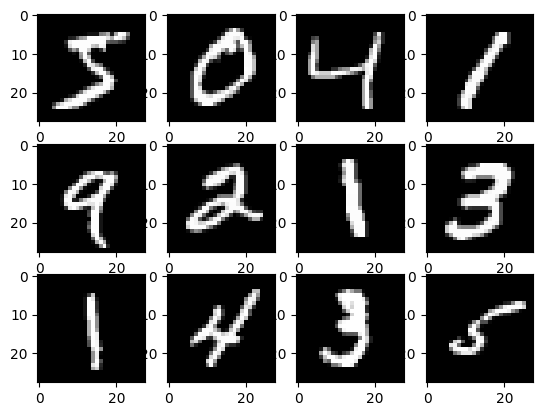

In [10]:
import matplotlib.pyplot as plt

for i in range(12):
    plt.subplot(3,4, i+1)
    plt.imshow(x_train[i, :, :], cmap='gray')  

In [11]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [12]:
x_train.shape

(60000, 28, 28, 1)

In [13]:
import numpy as np
# Pad images with 0s
# Transform 28x28 images into 32x32 images (by adding padding) that LeNet can process
x_train      = np.pad(x_train, ((0,0),(2,2),(2,2),(0,0)), 'constant')
x_test       = np.pad(x_test, ((0,0),(2,2),(2,2),(0,0)), 'constant')   

In [14]:
print("Updated Image Shape1: {}".format(x_train.shape))
print("Updated Image Shape2: {}".format(x_train[0].shape))

Updated Image Shape1: (60000, 32, 32, 1)
Updated Image Shape2: (32, 32, 1)


In [15]:
print(y_train)

[5 0 4 ... 5 6 8]


In [16]:
x_train[0].shape

(32, 32, 1)

In [17]:
# Normalization
x_train = x_train / 255
x_test = x_test / 255

# One Hot Encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [19]:
# Building the Model Architecture
model = Sequential()
model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(120, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

2024-02-28 17:16:21.045505: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-28 17:16:21.069748: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-28 17:16:21.069904: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [20]:
model.compile(loss=keras.metrics.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [21]:
model.fit(x_train, y_train, batch_size=128, epochs=20, verbose=1, validation_data=(x_test, y_test))

Epoch 1/20


2024-02-28 17:16:28.995698: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-02-28 17:16:29.090301: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-28 17:16:29.317981: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-28 17:16:29.382783: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fcb40c0caa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-28 17:16:29.382810: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2024-02-28 17:16:29.388464: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1709120789.474387   10337 device_compiler.

469/469 [==============================] - 5s 6ms/step - loss: 0.2976 - accuracy: 0.9133 - val_loss: 0.0940 - val_accuracy: 0.9697
Epoch 2/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0771 - accuracy: 0.9769 - val_loss: 0.0588 - val_accuracy: 0.9811
Epoch 3/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0551 - accuracy: 0.9834 - val_loss: 0.0434 - val_accuracy: 0.9861
Epoch 4/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0432 - accuracy: 0.9859 - val_loss: 0.0340 - val_accuracy: 0.9895
Epoch 5/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0346 - accuracy: 0.9891 - val_loss: 0.0351 - val_accuracy: 0.9888
Epoch 6/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0304 - accuracy: 0.9902 - val_loss: 0.0331 - val_accuracy: 0.9893
Epoch 7/20
469/469 [==============================] - 2s 4ms/step - loss: 0.0264 - accuracy: 0.9917 - val_loss: 0.0293 - val_accuracy: 0.9906
Epoch 8/20
469/46

In [22]:
score = model.evaluate(x_test, y_test)
print('Test Loss:', score[0])
print('Test accuracy:', score[1])

313/313 [==============================] - 1s 2ms/step - loss: 0.0423 - accuracy: 0.9899
Test Loss: 0.04228224977850914
Test accuracy: 0.9898999929428101


In [23]:
model.summary()
from tensorflow.keras.models import load_model, save_model
model.save('model.h5')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 120)               4

/home/alienblade/College Stuff/Workspace/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [25]:
# Load your trained model
model = load_model('model.h5')

# Preprocess the custom input image
input_image_path = '/home/alienblade/College Stuff/Workspace/download.jpeg'
input_image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)  # Read the image in grayscale
input_image = cv2.resize(input_image, (32, 32))  # Resize the image to match the input size of your model
input_image = np.expand_dims(input_image, axis=-1)  # Add a batch dimension
input_image = np.expand_dims(input_image, axis=0)  # Add a channel dimension

# Normalize the input image
input_image = input_image.astype('float32') / 255.0

# Make predictions
prediction = model.predict(input_image)
predicted_number = np.argmax(prediction)

print("Predicted Number:", predicted_number)


1/1 [==============================] - 0s 176ms/step
Predicted Number: 4


In [28]:
digit = int(input("Enter a single digit: "))
input_image = np.zeros((28, 28), dtype=np.uint8)
cv2.putText(input_image, str(digit), (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.8, 255, 2)

# Resize the image to match the input size of your model
input_image = cv2.resize(input_image, (32, 32))

# Add a batch dimension and normalize the input image
input_image = np.expand_dims(input_image, axis=-1) / 255.0
input_image = np.expand_dims(input_image, axis=0)

# Make predictions
prediction = model.predict(input_image)
predicted_number = np.argmax(prediction)

print("Predicted Number:", predicted_number)


1/1 [==============================] - 0s 17ms/step
Predicted Number: 6
